In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df= pd.read_csv("IBM_HR_analtyical.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool

In [7]:
unwanted_col= [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]
df.drop(columns=unwanted_col , inplace=True)

In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

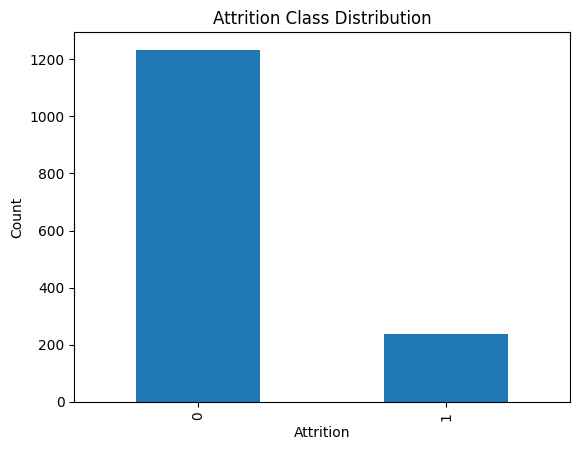

In [13]:
df["Attrition"].value_counts().plot(kind= "bar")
plt.title("Attrition Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

In [10]:
df["Attrition"]= df["Attrition"].str.strip()
df["Attrition"]= df["Attrition"].map({"Yes": 1, "No": 0})

In [ ]:
df["Attrition"].value_counts(normalize=True)*100 

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

In [14]:
#Identofay numerical and categorical features
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [15]:
#One- Hot encode catgeorical faetures

df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int )

In [16]:
X= df.drop("Attrition", axis=1) #fearures
y= df["Attrition"] #target

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Scale training data first
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [36]:
#Building Neural Network
from tensorflow.keras.layers import Dropout

model= Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid') #since binary classifciation probelm
])

In [37]:
#Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
#Train the model

# define early stopping to help the model stop before tend to overfit
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history= model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7383 - loss: 0.5547 - val_accuracy: 0.8347 - val_loss: 0.4504
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8170 - loss: 0.4812 - val_accuracy: 0.8305 - val_loss: 0.4261
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8266 - loss: 0.4447 - val_accuracy: 0.8305 - val_loss: 0.4130
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8266 - loss: 0.4425 - val_accuracy: 0.8305 - val_loss: 0.4022
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8298 - loss: 0.4348 - val_accuracy: 0.8305 - val_loss: 0.3921
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8330 - loss: 0.4203 - val_accuracy: 0.8305 - val_loss: 0.3854
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8372 - loss: 0.3995 - val_accuracy: 0.8305 - val_loss: 0.3776
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8415 - loss: 0.3881 - val_accuracy: 0.8305 - val_loss: 0.3

In [39]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8673 - loss: 0.4103 
Test Accuracy: 0.8673469424247742
Test Loss: 0.4103092849254608


In [40]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       247
           1       0.79      0.23      0.36        47

    accuracy                           0.87       294
   macro avg       0.83      0.61      0.64       294
weighted avg       0.86      0.87      0.84       294



In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       247
           1       0.79      0.23      0.36        47

    accuracy                           0.87       294
   macro avg       0.83      0.61      0.64       294
weighted avg       0.86      0.87      0.84       294

[[244   3]
 [ 36  11]]


In [42]:
#Need improve recall since we care more about the risk of employee leaving company
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8755 - loss: 0.5680 - val_accuracy: 0.8644 - val_loss: 0.3461
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8309 - loss: 0.4602 - val_accuracy: 0.8263 - val_loss: 0.3917
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8106 - loss: 0.4496 - val_accuracy: 0.8305 - val_loss: 0.4080
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8234 - loss: 0.4317 - val_accuracy: 0.8305 - val_loss: 0.3993
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7957 - loss: 0.4393 - val_accuracy: 0.8263 - val_loss: 0.4013
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8415 - loss: 0.4161 - val_accuracy: 0.8432 - val_loss: 0.3924


In [46]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.3).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       247
           1       0.32      0.68      0.44        47

    accuracy                           0.72       294
   macro avg       0.62      0.70      0.63       294
weighted avg       0.83      0.72      0.75       294

[[180  67]
 [ 15  32]]


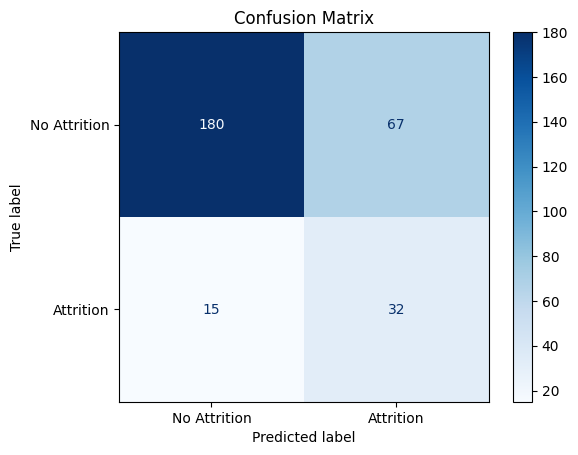

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

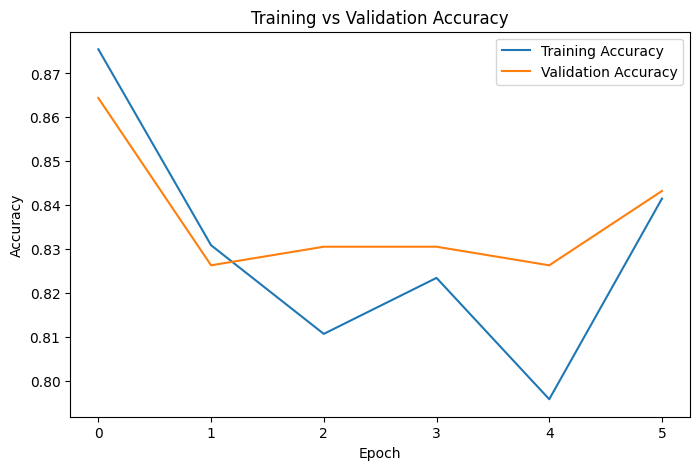

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

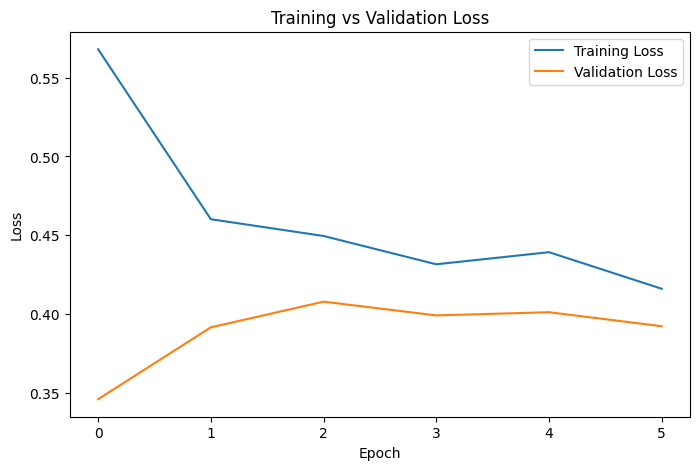

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
model.save("employee_attrition_model.keras")

In [ ]:
loaded_model = tf.keras.models.load_model("employee_attrition_model.keras")